# WandB Learning Curve Extractor

This notebook pulls experiment curves from WandB, filters runs by config, aggregates multiple seeds, and plots mean +- std.

## How to use
1. Update the configuration cell (entity, project, metrics, and experiment filters).
2. Run all cells.
3. Inspect matched run/seed summary and the generated plot.

In [1]:
import math
import os
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import wandb

# Optional: if you are not logged in yet, uncomment the next line.
# wandb.login()

print("Imports loaded.")

Imports loaded.


In [2]:
# -----------------------------
# User configuration (edit me)
# -----------------------------
DEFAULT_ENTITY = "glen-berseth"
DEFAULT_PROJECT = "purejaxrl_continuous_control_with_goals_from_mlp_teacher_lp_reward_more_seeds"

# Default learning-curve metrics used in this repo:
# x_metric="_step" and y_metric="episodic_return"
X_METRIC = "_step"
Y_METRIC = "eval/episodic_return"

# Allowed run states include: "finished", "running", "crashed", "failed"
ALLOWED_STATES = ["finished", "running", "crashed", "failed"]

# Speed/quality tradeoff when reading history:
# - "sampled": much faster, downsample each run history to SAMPLES_PER_RUN points
# - "scan": full history (slowest)
HISTORY_MODE = "sampled"
SAMPLES_PER_RUN = 2000
MAX_RUNS_PER_EXPERIMENT = None  # e.g. 30 to cap runtime on huge projects

# Aggregation options:
# - "union_interp": union of x grid, interpolate each run on that grid (recommended)
# - "union_exact": union of x grid, no interpolation (missing values become NaN)
# - "intersection_exact": only x values present in every run
ALIGNMENT_MODE = "union_interp"

SMOOTHING_WINDOW = 1  # set >1 for moving-average smoothing

PLOT_TITLE = "Ant-u-maze-single-goal"
X_LABEL = "Step"
Y_LABEL = "Episodic return"
FIGSIZE = (9, 5)
FONT_SIZE = 12  # title, axis labels, legend, and tick labels
LEGEND_LOC = "best"
SHADE_ALPHA = 0.2
LINEWIDTH = 2.0
SAVE_PATH = None  # Example: "artifacts/wandb_learning_curve.png"

# Define each experiment with filters and legend text.
# - "name": internal identifier
# - "legend": label shown on plot (optional, defaults to name)
# - Optional "entity" and "project": override defaults for this experiment
# - "config_filters": exact-match dict against run.config
# - Optional key "extra_predicate": callable (run) -> bool
EXPERIMENTS = [
    {
        "name": "exp_a",
        "legend": "Student with learning-progress based Teacher",
        # "entity": "glen-berseth",
        "project": "mlp_teacher_lp_reward_granular_sweep_over_teacher_eps_both_ent_coeff_teacher_lr_lp_ema_alpha_more_seeds",
        "config_filters": {
            "ENT_COEF": 0.0001,
            "LR": 0.0003,
            "TEACHER_LR": 0.0003,
            "TASK_REWARD_COEF": 1,
            "LP_EMA_ALPHA": 0.1,
            "TEACHER_LR": 0.0003,
            "TEACHER_CLIP_EPS": 0.2,
            "TEACHER_ENT_COEF": 0.01,
        },
    },
    # {
    #     "name": "exp_b",
    #     "legend": "Student with empowerment based Teacher",
    #     "entity": "glen-berseth",
    #     "project": "purejaxrl_continuous_control_with_goals_from_mlp_teacher_emp_subsample_emp_task_rewards_cofficients",
    #     "config_filters": {
    #         "ENT_COEF": 0.0,
    #         "TEACHER_NUM_MINIBATCHES": 8,
    #         "TEACHER_UPDATE_EPOCHS": 2,
    #         "TEACHER_ENT_COEF": 0.001,
    #         "LR": 0.0003,
    #         "TEACHER_LR": 0.0003,
    #         "NUM_ENVS": 256,
    #         "NUM_STEPS": 64,
    #         "NUM_MINIBATCHES": 8,
    #         "NUM_EVAL_ENVS": 8,
    #         "EMPOWERMENT_NUM_LAYERS": 3,
    #         "EMPOWERMENT_HIDDEN_DIM": 256,
    #         "EMPOWERMENT_CONTRASTIVE_LOSS": "fwd_infonce",
    #         "EMPOWERMENT_UPDATE_EPOCHS": 1,
    #         "TASK_REWARD_COEF": 5,
    #         # "SEED": 30
    #     },
    # },
    {
        "name": "exp_d",
        "legend": "Uniform Random Teacher",
        "entity": "glen-berseth",
        "project": "purejaxrl_ant_u_maze_single_goal_uniform_teacher_baseline_2",
        "config_filters": {
            "NUM_ENVS": 256,
            # "SEED": 30
        },
        # "extra_predicate": lambda run: "TEACHER_UNIFORM_RANDOM" not in (run.config or {}),

    },
    {
        "name": "exp_e",
        "legend": "Without Teacher",
        "entity": "glen-berseth",
        "project": "purejaxrl_ant_u_maze_single_goal_no_teacher_baseline_2",
        "config_filters": {
            "NUM_ENVS": 256,
            # "SEED": 30
        },
        # "extra_predicate": lambda run: "TEACHER_UNIFORM_RANDOM" not in (run.config or {}),

    },
    {
        "name": "exp_f",
        "legend": "Student + RND bonus",
        "entity": "glen-berseth",
        "project": "purejaxrl_ant_u_maze_single_goal_no_teacher_rnd_baseline",
        "config_filters": {
            "NUM_ENVS": 256,
            "RND_COEF": 1
            # "SEED": 30
        },
        # "extra_predicate": lambda run: "TEACHER_UNIFORM_RANDOM" not in (run.config or {}),

    },
]

if not DEFAULT_ENTITY or not DEFAULT_PROJECT:
    print("Set DEFAULT_ENTITY and DEFAULT_PROJECT before running plotting cells.")
else:
    print(f"Default source: {DEFAULT_ENTITY}/{DEFAULT_PROJECT}.")
print(f"History mode: {HISTORY_MODE}, samples/run: {SAMPLES_PER_RUN}")

Default source: glen-berseth/purejaxrl_continuous_control_with_goals_from_mlp_teacher_lp_reward_more_seeds.
History mode: sampled, samples/run: 2000


In [3]:
def _is_float_like(value: Any) -> bool:
    return isinstance(value, (float, np.floating)) and not isinstance(value, bool)


def _configs_equal(lhs: Any, rhs: Any) -> bool:
    if _is_float_like(lhs) or _is_float_like(rhs):
        try:
            return bool(math.isclose(float(lhs), float(rhs), rel_tol=1e-6, abs_tol=1e-9))
        except (TypeError, ValueError):
            return False
    return lhs == rhs


def run_matches_experiment(run: Any, experiment: Dict[str, Any], allowed_states: Sequence[str]) -> bool:
    if allowed_states and run.state not in allowed_states:
        return False

    config_filters = experiment.get("config_filters", {})
    run_config = dict(getattr(run, "config", {}) or {})
    for key, expected in config_filters.items():
        if key not in run_config:
            return False
        if not _configs_equal(run_config[key], expected):
            return False

    predicate = experiment.get("extra_predicate")
    if predicate is not None:
        return bool(predicate(run))

    return True


def _build_wandb_filters(
    config_filters: Optional[Dict[str, Any]],
    allowed_states: Sequence[str],
) -> Dict[str, Any]:
    filters: Dict[str, Any] = {}
    if allowed_states:
        filters["state"] = {"$in": list(allowed_states)}
    if config_filters:
        for key, value in config_filters.items():
            filters[f"config.{key}"] = value
    return filters


def fetch_runs(
    api: Any,
    entity: str,
    project: str,
    config_filters: Optional[Dict[str, Any]] = None,
    allowed_states: Sequence[str] = (),
) -> List[Any]:
    filters = _build_wandb_filters(config_filters, allowed_states)
    return list(api.runs(f"{entity}/{project}", filters=filters))

In [4]:
def extract_xy_from_run(
    run: Any,
    x_metric: str,
    y_metric: str,
    history_mode: str = "sampled",
    samples_per_run: int = 2000,
) -> Optional[Dict[str, Any]]:
    if history_mode == "scan":
        history_rows = run.scan_history(keys=[x_metric, y_metric])
    elif history_mode == "sampled":
        history_rows = run.history(
            keys=[x_metric, y_metric],
            samples=samples_per_run,
            pandas=False,
        )
    else:
        raise ValueError(f"Unknown HISTORY_MODE: {history_mode}")

    if hasattr(history_rows, "to_dict"):
        history_rows = history_rows.to_dict("records")

    rows: List[Tuple[float, float]] = []
    for row in history_rows:
        x_val = row.get(x_metric)
        y_val = row.get(y_metric)
        if x_val is None or y_val is None:
            continue
        if isinstance(x_val, (int, float, np.integer, np.floating)) and isinstance(
            y_val, (int, float, np.integer, np.floating)
        ):
            if np.isfinite(x_val) and np.isfinite(y_val):
                rows.append((float(x_val), float(y_val)))

    if not rows:
        return None

    x = np.array([r[0] for r in rows], dtype=np.float64)
    y = np.array([r[1] for r in rows], dtype=np.float64)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    # Collapse duplicate x values by averaging their y values.
    unique_x, inverse = np.unique(x, return_inverse=True)
    y_sum = np.zeros_like(unique_x, dtype=np.float64)
    y_count = np.zeros_like(unique_x, dtype=np.int64)
    for idx, inv in enumerate(inverse):
        y_sum[inv] += y[idx]
        y_count[inv] += 1
    unique_y = y_sum / np.maximum(y_count, 1)

    seed = dict(getattr(run, "config", {}) or {}).get("SEED")
    seed_key = seed if seed is not None else f"run:{run.id}"
    return {
        "run_id": run.id,
        "run_name": run.name,
        "seed": seed,
        "seed_key": seed_key,
        "x": unique_x,
        "y": unique_y,
    }


def moving_average(values: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return values
    kernel = np.ones(window, dtype=np.float64) / float(window)
    valid = np.isfinite(values).astype(np.float64)
    filled = np.where(np.isfinite(values), values, 0.0)
    num = np.convolve(filled, kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    out = np.full_like(values, np.nan, dtype=np.float64)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out


def _align_curves(
    x_arrays: Sequence[np.ndarray],
    y_arrays: Sequence[np.ndarray],
    alignment_mode: str,
) -> Tuple[np.ndarray, np.ndarray]:
    if alignment_mode == "intersection_exact":
        common = set(x_arrays[0].tolist())
        for x in x_arrays[1:]:
            common &= set(x.tolist())
        if not common:
            return np.array([], dtype=np.float64), np.empty((0, 0), dtype=np.float64)
        x_grid = np.array(sorted(common), dtype=np.float64)
        matrix = []
        for x, y in zip(x_arrays, y_arrays):
            mapping = {float(k): float(v) for k, v in zip(x, y)}
            matrix.append(np.array([mapping[val] for val in x_grid], dtype=np.float64))
        return x_grid, np.vstack(matrix)

    x_grid = np.unique(np.concatenate(x_arrays).astype(np.float64))
    y_matrix = np.full((len(x_arrays), len(x_grid)), np.nan, dtype=np.float64)
    for i, (x, y) in enumerate(zip(x_arrays, y_arrays)):
        if alignment_mode == "union_interp":
            y_matrix[i] = np.interp(x_grid, x, y, left=np.nan, right=np.nan)
        elif alignment_mode == "union_exact":
            positions = np.searchsorted(x_grid, x)
            y_matrix[i, positions] = y
        else:
            raise ValueError(f"Unknown alignment mode: {alignment_mode}")
    return x_grid, y_matrix


def _aggregate_xy_curves(
    curves: Sequence[Tuple[np.ndarray, np.ndarray]], alignment_mode: str
) -> Optional[Dict[str, np.ndarray]]:
    if not curves:
        return None
    x_arrays = [c[0] for c in curves]
    y_arrays = [c[1] for c in curves]
    x_grid, y_matrix = _align_curves(x_arrays, y_arrays, alignment_mode)
    if y_matrix.size == 0:
        return None

    mean = np.nanmean(y_matrix, axis=0)
    std = np.nanstd(y_matrix, axis=0)
    count = np.sum(~np.isnan(y_matrix), axis=0)
    valid = count > 0
    if not np.any(valid):
        return None

    return {
        "x": x_grid[valid],
        "mean": mean[valid],
        "std": std[valid],
        "count": count[valid],
    }


def aggregate_records_by_seed(
    records: Sequence[Dict[str, Any]], alignment_mode: str
) -> Optional[Dict[str, Any]]:
    if not records:
        return None

    per_seed: Dict[str, List[Tuple[np.ndarray, np.ndarray]]] = {}
    for record in records:
        key = str(record["seed_key"])
        per_seed.setdefault(key, []).append((record["x"], record["y"]))

    # If multiple runs share a seed, average those runs first.
    seed_curves: List[Tuple[np.ndarray, np.ndarray]] = []
    for seed_runs in per_seed.values():
        seed_agg = _aggregate_xy_curves(seed_runs, alignment_mode)
        if seed_agg is None:
            continue
        seed_curves.append((seed_agg["x"], seed_agg["mean"]))

    overall = _aggregate_xy_curves(seed_curves, alignment_mode)
    if overall is None:
        return None

    overall["num_seeds"] = np.array([len(seed_curves)], dtype=np.int64)
    return overall

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mila/f/faisal.mohamed/.netrc.


Queried experiment sources:
[exp_a | legend=Student with learning-progress based Teacher] source=glen-berseth/mlp_teacher_lp_reward_granular_sweep_over_teacher_eps_both_ent_coeff_teacher_lr_lp_ema_alpha_more_seeds fetched_runs=3 matched_runs=3 curve_runs=3 unique_seeds=[30, 123, 75937]
[exp_d | legend=Uniform Random Teacher] source=glen-berseth/purejaxrl_ant_u_maze_single_goal_uniform_teacher_baseline_2 fetched_runs=3 matched_runs=3 curve_runs=3 unique_seeds=[0, 30, 8943]
[exp_e | legend=Without Teacher] source=glen-berseth/purejaxrl_ant_u_maze_single_goal_no_teacher_baseline_2 fetched_runs=3 matched_runs=3 curve_runs=3 unique_seeds=[0, 30, 8943]
[exp_f | legend=Student + RND bonus] source=glen-berseth/purejaxrl_ant_u_maze_single_goal_no_teacher_rnd_baseline fetched_runs=6 matched_runs=6 curve_runs=6 unique_seeds=[0, 30, 123, 8943, 75937]
Saved figure to: ../plots/Ant-u-maze-single-goal_eval/episodic_return.png


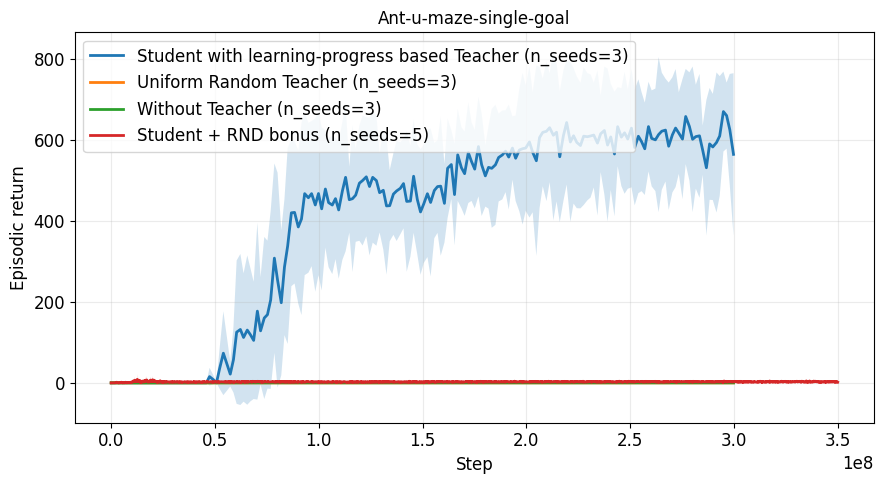

In [5]:
needs_default_source = any(
    (not exp.get("entity")) or (not exp.get("project")) for exp in EXPERIMENTS
)
if needs_default_source and (not DEFAULT_ENTITY or not DEFAULT_PROJECT):
    raise ValueError(
        "Set DEFAULT_ENTITY and DEFAULT_PROJECT, or provide entity/project on every experiment."
    )

api = wandb.Api(timeout=60)

# Caches speed up repeated runs of this cell.
runs_cache: Dict[Tuple[str, str, Tuple[Tuple[str, Any], ...], Tuple[str, ...]], List[Any]] = {}
history_cache: Dict[Tuple[str, str, str, str, int], Optional[Dict[str, Any]]] = {}


def get_runs_for_experiment(entity: str, project: str, exp: Dict[str, Any]) -> List[Any]:
    config_filters = exp.get("config_filters", {})
    allowed_states_key = tuple(sorted(ALLOWED_STATES))
    filter_items = tuple(sorted(config_filters.items()))
    cache_key = (entity, project, filter_items, allowed_states_key)
    if cache_key not in runs_cache:
        runs_cache[cache_key] = fetch_runs(
            api=api,
            entity=entity,
            project=project,
            config_filters=config_filters,
            allowed_states=ALLOWED_STATES,
        )
    return runs_cache[cache_key]


def build_plot_payloads(
    experiments: Sequence[Dict[str, Any]],
    *,
    default_entity: Optional[str] = None,
    default_project: Optional[str] = None,
    x_metric: Optional[str] = None,
    y_metric: Optional[str] = None,
    history_mode: Optional[str] = None,
    samples_per_run: Optional[int] = None,
    max_runs_per_experiment: Optional[int] = None,
    alignment_mode: Optional[str] = None,
    smoothing_window: Optional[int] = None,
    verbose: bool = True,
) -> Tuple[List[Tuple[str, str, Dict[str, Any], List[Dict[str, Any]]]], Dict[str, Dict[str, Any]]]:
    """Fetch and aggregate mean±std curves for a list of experiment configs."""
    entity_default = DEFAULT_ENTITY if default_entity is None else default_entity
    project_default = DEFAULT_PROJECT if default_project is None else default_project
    x_key = X_METRIC if x_metric is None else x_metric
    y_key = Y_METRIC if y_metric is None else y_metric
    hist_mode = HISTORY_MODE if history_mode is None else history_mode
    n_samples = SAMPLES_PER_RUN if samples_per_run is None else samples_per_run
    max_runs = MAX_RUNS_PER_EXPERIMENT if max_runs_per_experiment is None else max_runs_per_experiment
    align_mode = ALIGNMENT_MODE if alignment_mode is None else alignment_mode
    smooth_window = SMOOTHING_WINDOW if smoothing_window is None else smoothing_window

    plot_payloads: List[Tuple[str, str, Dict[str, Any], List[Dict[str, Any]]]] = []
    summary_by_experiment: Dict[str, Dict[str, Any]] = {}

    for exp in experiments:
        exp_name = exp["name"]
        exp_legend = exp.get("legend", exp_name)
        exp_entity = exp.get("entity", entity_default)
        exp_project = exp.get("project", project_default)

        if not exp_entity or not exp_project:
            raise ValueError(
                f"Experiment '{exp_name}' must resolve to a non-empty entity and project."
            )

        candidate_runs = get_runs_for_experiment(exp_entity, exp_project, exp)
        if max_runs is not None:
            candidate_runs = candidate_runs[:max_runs]

        matched_runs = [
            run for run in candidate_runs if run_matches_experiment(run, exp, ALLOWED_STATES)
        ]

        records = []
        for run in matched_runs:
            hist_key = (run.id, x_key, y_key, hist_mode, int(n_samples))
            if hist_key not in history_cache:
                history_cache[hist_key] = extract_xy_from_run(
                    run,
                    x_key,
                    y_key,
                    history_mode=hist_mode,
                    samples_per_run=n_samples,
                )
            item = history_cache[hist_key]
            if item is not None:
                records.append(item)

        summary_by_experiment[exp_name] = {
            "legend": exp_legend,
            "entity": exp_entity,
            "project": exp_project,
            "fetched_runs": len(candidate_runs),
            "matched_runs": len(matched_runs),
            "records": records,
        }

        agg = aggregate_records_by_seed(records, align_mode)
        if agg is not None and smooth_window > 1:
            agg["mean"] = moving_average(agg["mean"], smooth_window)
            agg["std"] = moving_average(agg["std"], smooth_window)

        if agg is not None:
            plot_payloads.append((exp_name, exp_legend, agg, records))

    if verbose:
        print("Queried experiment sources:")
        for exp in experiments:
            exp_name = exp["name"]
            stats = summary_by_experiment[exp_name]
            records_for_exp = stats["records"]
            seen_seed_keys = sorted({str(r["seed_key"]) for r in records_for_exp})
            printable_seeds = sorted(
                {r["seed"] for r in records_for_exp if r.get("seed") is not None}
            )
            print(
                f"[{exp_name} | legend={stats['legend']}] "
                f"source={stats['entity']}/{stats['project']} "
                f"fetched_runs={stats['fetched_runs']} "
                f"matched_runs={stats['matched_runs']} "
                f"curve_runs={len(records_for_exp)} "
                f"unique_seeds={printable_seeds if printable_seeds else seen_seed_keys}"
            )
            if not records_for_exp:
                print(f"  Warning: no history found for metrics ({x_key}, {y_key}).")

    return plot_payloads, summary_by_experiment


plot_payloads, summary_by_experiment = build_plot_payloads(EXPERIMENTS)

if not plot_payloads:
    raise ValueError("No plottable experiment data found. Check filters/metrics.")

plt.rcParams.update(
    {
        "font.size": FONT_SIZE,
        "axes.titlesize": FONT_SIZE,
        "axes.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE,
        "ytick.labelsize": FONT_SIZE,
    }
)
plt.figure(figsize=FIGSIZE)
for exp_name, exp_legend, agg, _ in plot_payloads:
    label = exp_legend
    x = agg["x"]
    mean = agg["mean"]
    std = agg["std"]
    n_seeds = int(agg["num_seeds"][0])
    if n_seeds > 0:
        label = f"{exp_legend} (n_seeds={n_seeds})"
    plt.plot(x, mean, label=label, linewidth=LINEWIDTH)
    plt.fill_between(x, mean - std, mean + std, alpha=SHADE_ALPHA)

plt.title(PLOT_TITLE)
plt.xlabel(X_LABEL)
plt.ylabel(Y_LABEL)
plt.legend(loc=LEGEND_LOC)
plt.grid(alpha=0.25)
plt.tight_layout()

SAVE_PATH = f"../plots/{PLOT_TITLE}_{Y_METRIC}.png"
SAVE_PATH_PDF = f"../plots/{PLOT_TITLE}_{Y_METRIC}.pdf"

if SAVE_PATH:
    os.makedirs(os.path.dirname(SAVE_PATH) or ".", exist_ok=True)
    plt.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
    plt.savefig(SAVE_PATH_PDF, dpi=200, bbox_inches="tight")
    print(f"Saved figure to: {SAVE_PATH}")

plt.show()


In [41]:
def format_env_title(env_name: str) -> str:
    """Strip a trailing single-goal suffix for subplot titles."""
    cleaned = env_name.strip()
    suffixes = (
        "_single_goal",
        "-single-goal",
        " single goal",
        "_single-goal",
        "-single_goal",
    )
    lower = cleaned.lower()
    for suffix in suffixes:
        if lower.endswith(suffix):
            cleaned = cleaned[: -len(suffix)].capitalize()
            cleaned = cleaned.replace("_", " ")
            return cleaned
    return cleaned.capitalize()


def _resolve_colormap(cmap: Union[str, Any]):
    if isinstance(cmap, str):
        return plt.get_cmap(cmap)
    return cmap


def _colors_from_cmap(cmap: Union[str, Any], n: int) -> List[Any]:
    colormap = _resolve_colormap(cmap)
    if n <= 0:
        return []
    if n == 1:
        return [colormap(0.0)]
    # Prefer discrete sampling for qualitative maps; fall back to linspace.
    if hasattr(colormap, "colors") and len(getattr(colormap, "colors", [])) >= n:
        return [colormap(i) for i in range(n)]
    return [colormap(i / (n - 1)) for i in range(n)]


def _curve_label(exp_legend: str, agg: Dict[str, Any]) -> str:
    n_seeds = int(agg["num_seeds"][0])
    if n_seeds > 0:
        return f"{exp_legend}"
    return exp_legend



def plot_environments_learning_curves_row(
    environments: Sequence[Dict[str, Any]],
    *,
    cmap: Union[str, Any] = "tab10",
    figsize: Optional[Tuple[float, float]] = None,
    font: Optional[str] = None,
    font_size: float = 9,
    linewidth: float = 2.0,
    shade_alpha: float = 0.2,
    x_label: str = "Step",
    y_label: str = "Episodic return",
    save_path: Optional[str] = None,
    grid_alpha: float = 0.15,
    y_nbins: int = 5,
    legend_nrows: int = 3,
    legend_ncols: Optional[int] = None,
    dpi: int = 200,
) -> plt.Figure:
    """Plot learning curves for multiple environments in a single row.

    Each entry in ``environments`` should look like::

        {
            "name": "ant_u_maze_single_goal",
            "experiments": [...],  # same schema as EXPERIMENTS
        }

    ``cmap`` selects the matplotlib colormap used for methods (shared across panels).
    ``font`` selects the font family (``None`` keeps matplotlib's default;
    e.g. ``"Times New Roman"``). ``legend_nrows`` / ``legend_ncols`` control the
    shared legend layout: if ``legend_ncols`` is set it is used directly; otherwise
    columns are derived from ``legend_nrows`` (default 3). When ``save_path``
    is set, both PNG and PDF versions are written.
    """
    if not environments:
        raise ValueError("environments must be a non-empty sequence.")

    env_payloads: List[Tuple[str, List[Tuple[str, str, Dict[str, Any], List[Dict[str, Any]]]]]] = []
    for env in environments:
        env_name = env["name"]
        experiments = env.get("experiments", [])
        if not experiments:
            raise ValueError(f"Environment '{env_name}' has no experiments.")
        print(f"\n=== Environment: {env_name} ===")
        payloads, _ = build_plot_payloads(experiments, verbose=True)
        if not payloads:
            raise ValueError(
                f"No plottable experiment data found for environment '{env_name}'."
            )
        env_payloads.append((env_name, payloads))

    # Canonical legend/color order from the first environment; shared across panels.
    legend_order: List[str] = []
    legend_labels: Dict[str, str] = {}
    for exp_name, exp_legend, agg, _ in env_payloads[0][1]:
        legend_order.append(exp_name)
        legend_labels[exp_name] = _curve_label(exp_legend, agg)

    for env_name, payloads in env_payloads[1:]:
        for exp_name, exp_legend, agg, _ in payloads:
            if exp_name not in legend_labels:
                legend_order.append(exp_name)
                legend_labels[exp_name] = _curve_label(exp_legend, agg)

    colors = _colors_from_cmap(cmap, len(legend_order))
    color_by_exp = {name: colors[i] for i, name in enumerate(legend_order)}

    n_envs = len(env_payloads)
    if figsize is None:
        figsize = (3.2 * n_envs, 3.2)

    # None keeps matplotlib's current default font family.
    prev_font_family = plt.rcParams["font.family"]
    prev_pdf_fonttype = plt.rcParams["pdf.fonttype"]
    try:
        if font is not None:
            plt.rcParams["font.family"] = font
            # Embed TrueType fonts in PDF so Times New Roman (etc.) survives export.
            plt.rcParams["pdf.fonttype"] = 42

        fig, axes = plt.subplots(1, n_envs, figsize=figsize, sharey=False)
        if n_envs == 1:
            axes = [axes]

        legend_handles = {}
        for ax, (env_name, payloads) in zip(axes, env_payloads):
            for exp_name, exp_legend, agg, _ in payloads:
                color = color_by_exp[exp_name]
                label = legend_labels.get(exp_name, _curve_label(exp_legend, agg))
                (line,) = ax.plot(
                    agg["x"],
                    agg["mean"],
                    label=label,
                    linewidth=linewidth,
                    color=color,
                )
                ax.fill_between(
                    agg["x"],
                    agg["mean"] - agg["std"],
                    agg["mean"] + agg["std"],
                    alpha=shade_alpha,
                    color=color,
                )
                if exp_name not in legend_handles:
                    legend_handles[exp_name] = line

            ax.set_title(format_env_title(env_name), fontweight="bold", fontsize=font_size)
            ax.set_xlabel(x_label, fontsize=font_size)
            ax.tick_params(axis="both", labelsize=font_size)
            ax.yaxis.set_major_locator(MaxNLocator(nbins=y_nbins))
            ax.grid(True, alpha=grid_alpha)

        axes[0].set_ylabel(y_label, fontsize=font_size)

        handles = [legend_handles[name] for name in legend_order if name in legend_handles]
        labels = [legend_labels[name] for name in legend_order if name in legend_handles]
        n_entries = max(len(handles), 1)
        if legend_ncols is not None:
            legend_ncol = max(int(legend_ncols), 1)
        else:
            nrows = max(int(legend_nrows), 1)
            legend_ncol = max(1, math.ceil(n_entries / nrows))
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=legend_ncol,
            frameon=False,
            fontsize=font_size,
        )
        fig.tight_layout()

        if save_path:
            stem = save_path
            lower = stem.lower()
            if lower.endswith(".png") or lower.endswith(".pdf"):
                stem = stem.rsplit(".", 1)[0]
            png_path = f"{stem}.png"
            pdf_path = f"{stem}.pdf"
            parent = os.path.dirname(png_path)
            if parent:
                os.makedirs(parent, exist_ok=True)
            fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
            fig.savefig(pdf_path, dpi=dpi, bbox_inches="tight")
            print(f"Saved figure to: {png_path}")
            print(f"Saved figure to: {pdf_path}")

        plt.show()
        return fig
    finally:
        plt.rcParams["font.family"] = prev_font_family
        plt.rcParams["pdf.fonttype"] = prev_pdf_fonttype


print("Multi-environment plotting helpers loaded.")


Multi-environment plotting helpers loaded.


In [52]:
ANT_U_MAZE_EXPERIMENTS = [
    {
        "name": "exp_a",
        "legend": "PPO + learning-progress based Teacher (Ours)",
        # "entity": "glen-berseth",
        "project": "lp_teacher_all_envs_final",
        "config_filters": {
            "TASK_REWARD_COEF": 1,
            "LP_EMA_ALPHA": 0.1,
            "TEACHER_LR": 0.0003,
            "TEACHER_ENT_COEF": 0.01,
            "NUM_ENVS": 512,
            "TOTAL_TIMESTEPS":350000000,
            "ENV_NAME": "ant_u_maze_single_goal",

        },
    },
    {
        "name": "exp_b",
        "legend": "PPO",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_no_teacher_baseline",
        "config_filters": {
            "ENV_NAME": "ant_u_maze_single_goal",

        },
    },
    {
        "name": "exp_c",
        "legend": "PPO + Oracle Teacher",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_oracle_teacher_baseline",
        "config_filters": {
            "ENV_NAME": "ant_u_maze_single_goal",

        },
    },
     {
        "name": "exp_d",
        "legend": "PPO + Uniform Teacher",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_uniform_teacher_baseline",
        "config_filters": {
            "ENV_NAME": "ant_u_maze_single_goal",

        },
    },
    {
        "name": "exp_e",
        "legend": "PPO + ICM",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_no_teacher_icm_baseline",
        "config_filters": {
            "ENV_NAME": "ant_u_maze_single_goal",
            "ICM_COEF": 0.01,

        },
    },
    {
        "name": "exp_f",
        "legend": "Student + RND",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_no_teacher_rnd_baseline",
        "config_filters": {
            "ENV_NAME": "ant_u_maze_single_goal",
            "RND_COEF": 1,

        },
    },
]
ANT_BIG_MAZE_EXPERIMENTS = [
    {
        "name": "exp_a",
        "legend": "Student with learning-progress based Teacher (Ours)",
        # "entity": "glen-berseth",
        "project": "lp_teacher_all_envs_final",
        "config_filters": {
            "TASK_REWARD_COEF": 1,
            "LP_EMA_ALPHA": 0.1,
            "TEACHER_LR": 0.0003,
            "TEACHER_ENT_COEF": 0.005,
            "NUM_ENVS": 512,
            "TOTAL_TIMESTEPS":350000000,
            "ENV_NAME": "ant_big_maze_single_goal",

        },
    },
     {
        "name": "exp_b",
        "legend": "Student without Teacher",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_no_teacher_baseline",
        "config_filters": {
            "ENV_NAME": "ant_big_maze_single_goal",

        },
    },
     {
        "name": "exp_c",
        "legend": "Student With Oracle Teacher",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_oracle_teacher_baseline",
        "config_filters": {
            "ENV_NAME": "ant_big_maze_single_goal",

        },
    },
    {
        "name": "exp_d",
        "legend": "Student With Uniform Teacher",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_uniform_teacher_baseline",
        "config_filters": {
            "ENV_NAME": "ant_big_maze_single_goal",

        },
    },
    {
        "name": "exp_e",
        "legend": "Student With ICM",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_no_teacher_icm_baseline",
        "config_filters": {
            "ENV_NAME": "ant_big_maze_single_goal",
            "ICM_COEF": 0.01,

        },
    },
    {
        "name": "exp_f",
        "legend": "Student With RND",
        # "entity": "glen-berseth",
        "project": "purejaxrl_all_envs_no_teacher_rnd_baseline",
        "config_filters": {
            "ENV_NAME": "ant_big_maze_single_goal",
            "RND_COEF": 1,

        },
    },
]


=== Environment: ant_u_maze_single_goal ===
Queried experiment sources:
[exp_a | legend=PPO + learning-progress based Teacher (Ours)] source=glen-berseth/lp_teacher_all_envs_final fetched_runs=5 matched_runs=5 curve_runs=5 unique_seeds=[1, 30, 123, 75937, 842434353]
[exp_b | legend=PPO] source=glen-berseth/purejaxrl_all_envs_no_teacher_baseline fetched_runs=5 matched_runs=5 curve_runs=5 unique_seeds=[1, 30, 123, 75937, 842434353]
[exp_c | legend=PPO + Oracle Teacher] source=glen-berseth/purejaxrl_all_envs_oracle_teacher_baseline fetched_runs=5 matched_runs=5 curve_runs=5 unique_seeds=[1, 30, 123, 75937, 842434353]
[exp_d | legend=PPO + Uniform Teacher] source=glen-berseth/purejaxrl_all_envs_uniform_teacher_baseline fetched_runs=5 matched_runs=5 curve_runs=5 unique_seeds=[1, 30, 123, 75937, 842434353]
[exp_e | legend=PPO + ICM] source=glen-berseth/purejaxrl_all_envs_no_teacher_icm_baseline fetched_runs=5 matched_runs=5 curve_runs=5 unique_seeds=[1, 30, 123, 75937, 842434353]
[exp_f | l

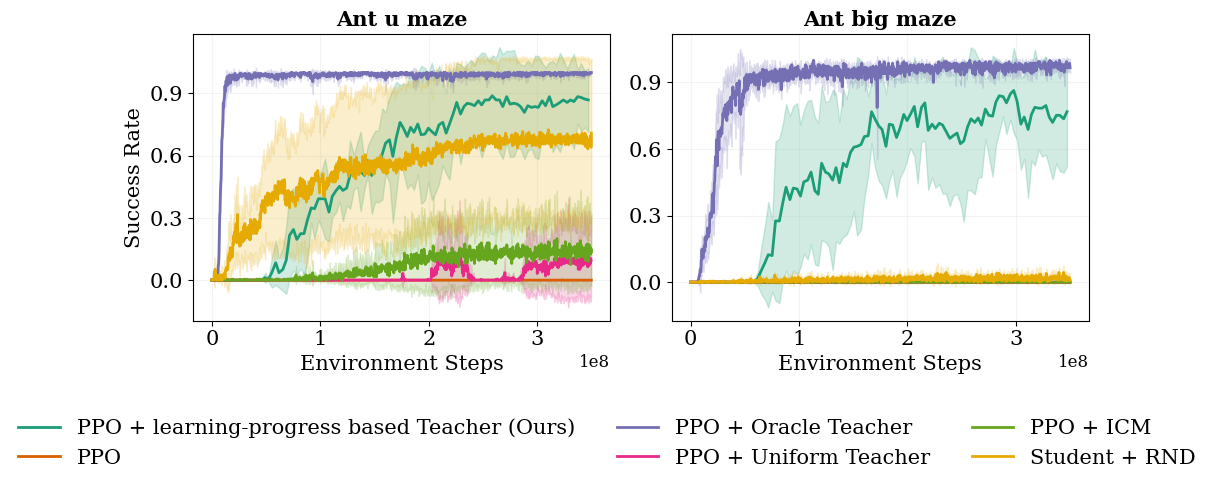

In [56]:
# Multi-environment row plot
# Each environment has the same experiment schema as EXPERIMENTS above.
ENVIRONMENTS = [
    {
        "name": "ant_u_maze_single_goal",
        "experiments": ANT_U_MAZE_EXPERIMENTS,  # reuse the config-cell experiments for this env
    },
    {
        "name": "ant_big_maze_single_goal",
        "experiments": ANT_BIG_MAZE_EXPERIMENTS,
    },
    # {
    #     "name": "ant_big_maze_single_goal",
    #     "experiments": [
    #         {
    #             "name": "exp_a",
    #             "legend": "Student with learning-progress based Teacher",
    #             "project": "...",
    #             "config_filters": {...},
    #         },
    #         # ... other methods for this environment ...
    #     ],
    # },
]

# Explicit colormap option (e.g. "tab10", "Set2", "Dark2", "viridis").
ROW_CMAP = "Dark2"
# Font family: None keeps matplotlib's default; try "Times New Roman" for papers.
# ROW_FONT = None  # e.g. "Times New Roman"
ROW_FONT = "serif"
figSize = (10, 4)
X_LABEL="Environment Steps"
Y_LABEL="Success Rate"
Y_METRIC="eval/success_rate"

fig_row = plot_environments_learning_curves_row(
    ENVIRONMENTS,
    cmap=ROW_CMAP,
    font=ROW_FONT,
    font_size=15,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    linewidth=LINEWIDTH,
    shade_alpha=SHADE_ALPHA,
    save_path=f"../plots/learning_curves_row_{Y_METRIC}",
    figsize=figSize,
    dpi=350,
    legend_nrows=2,
    legend_ncols=3,  # if set, overrides legend_nrows
)
